# Predictive Modelling for Credit Card Default Using Machine Learning

**MSc in Artificial Intelligence — Introduction to Artificial Intelligence**

This notebook addresses all five tasks of the assignment:

1. **Task 1** — Exploratory Data Analysis (EDA)
2. **Task 2** — Data Preparation (missing values, outliers, encoding, scaling)
3. **Task 3** — Model Training (Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Gradient Boosting, XGBoost)
4. **Task 4** — Model Evaluation, Hyperparameter Tuning, and SHAP Interpretation
5. **Task 5** — Conclusion, Limitations, and Future Work

The dataset (`Credit_Card.csv`, 34,788 rows × 30 columns) covers credit-card clients betIen April and September 2005. The target `default.payment.next.month` is binary (1 = default).

> **Note on data quality.** The provided file uses **`;` as the field separator** and contains two columns, `risk_leak` and `LIMIT_BAL_LOG`, that have been corrupted by locale-aware spreadsheet formatting (dots used as thousand separators, commas as decimals, mixed scientific notation). These are cleaned before analysis. The column `risk_leak` is also a **target leak** by construction — its magnitude almost perfectly separates the two classes — and is therefore *excluded* from the predictive models, although it is analysed and discussed.


## 0. Setup — Imports and Configuration

In [1]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install xgboost
# !pip install lightgbm
# !pip install catboost
# !pip install statsmodels
# !pip install numpy
# !pip install shap
!pip install jinja2


In [2]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-processing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix, classification_report
)

# Interpretation
import shap

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Load the Dataset and Repair Corrupted Columns

The CSV uses `;` as separator. Two columns (`risk_leak`, `LIMIT_BAL_LOG`) Ire exported in a way that lost their decimal point — dots act as thousand-separators on a digit string. I handle this **before any other analysis**, otherwise these columns would be unusable.

In [3]:
# Load with semicolon separator
df_raw = pd.read_csv("Credit_Card.csv", sep=";", low_memory=False)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1


In [ ]:
# Inspect the corruption pattern in risk_leak
def n_dots(x):
    return -1 if pd.isna(x) else str(x).count(".")

print("Number of dots in risk_leak values (counts):")
print(df_raw["risk_leak"].apply(n_dots).value_counts().sort_index())

print("\nNumber of dots in LIMIT_BAL_LOG values (counts):")
print(df_raw["LIMIT_BAL_LOG"].apply(n_dots).value_counts().sort_index())

print("\nExamples with multiple dots in risk_leak:")
print(df_raw.loc[df_raw["risk_leak"].apply(lambda x: n_dots(x) >= 3), "risk_leak"].head(5).tolist())

Number of dots in risk_leak values (counts):
risk_leak
0       31
1    31401
3        1
4       79
5     3276
Name: count, dtype: int64

Number of dots in LIMIT_BAL_LOG values (counts):
LIMIT_BAL_LOG
-1     1709
 4     2117
 5    30962
Name: count, dtype: int64

Examples with multiple dots in risk_leak:
['1.075.675.276.433.290', '10.940.840.854.872.400', '10.766.903.772.701.800', '10.975.965.043.738.200', '11.604.223.815.204.400']


**Interpretation of the corruption.** A value such as `1.075.675.276.433.290` is the digit string `1075675276433290` formatted with `.` as thousand-separators (European convention). Removing all dots recovers the magnitude as an integer. A value such as `-2,00E+11` is scientific notation that uses `,` as decimal. A value such as `0.0703022492301175` is a normal float. I write a single parser that handles all three forms.

In [6]:
def parse_risk_leak(x):
    """Robust parser for the corrupted risk_leak column."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # Scientific notation, possibly with comma decimal
    if "E" in s.upper() or "e" in s:
        try:
            return float(s.replace(",", "."))
        except ValueError:
            return np.nan
    sign = -1.0 if s.startswith("-") else 1.0
    s = s.lstrip("-")
    if s.count(".") <= 1:
        # Normal float
        try:
            return sign * float(s)
        except ValueError:
            return np.nan
    # Multi-dot: European thousand-separator on a digit string -> integer
    digits = s.replace(".", "")
    try:
        return sign * float(digits)
    except ValueError:
        return np.nan

# Apply
df = df_raw.copy()
df["risk_leak"] = df["risk_leak"].apply(parse_risk_leak)

# LIMIT_BAL_LOG is fully redundant (= log(LIMIT_BAL)) and corrupted -> recompute
df["LIMIT_BAL_LOG"] = np.log(df["LIMIT_BAL"])  # NaNs propagate where LIMIT_BAL is NaN

print("After repair:")
print(df[["risk_leak", "LIMIT_BAL", "LIMIT_BAL_LOG"]].describe())

After repair:
          risk_leak     LIMIT_BAL  LIMIT_BAL_LOG
count  3.478800e+04  3.307900e+04   33079.000000
mean   8.295598e+14  1.846690e+05      11.698203
std    2.844177e+15  2.359319e+05       0.967123
min   -5.350000e+11  1.000000e+04       9.210340
25%   -5.102190e-02  6.000000e+04      11.002100
50%    3.065539e-02  1.400000e+05      11.849398
75%    1.471091e-01  2.400000e+05      12.388394
max    1.396316e+16  5.600000e+06      15.538277


## 2. Task 1 - Exploratory Data Analysis

I investigate distributions, descriptive statistics, correlations, and the relationship betIen each feature and the target. Particular attention is given to `risk_leak`, `RISK_RATING`, and `PAY_0`–`PAY_6`.

### 2.1 Basic shape and column overview

In [7]:
print("Dataset shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (34788, 30)

Column dtypes:
 ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
risk_l

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075675e+15,7704.0,9.903488,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,1.094084e+16,17077.0,11.695247,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,7.030225e-02,101653.0,11.407565,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,5.844244e-02,231334.0,10.819778,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,1.294310e-01,109339.0,10.819778,City_44,1


### 2.2 Target distribution and class imbalance

Class distribution:
  Non-default (0): 28,132  (80.87%)
  Default     (1): 6,656  (19.13%)
  Imbalance ratio: 4.23 : 1


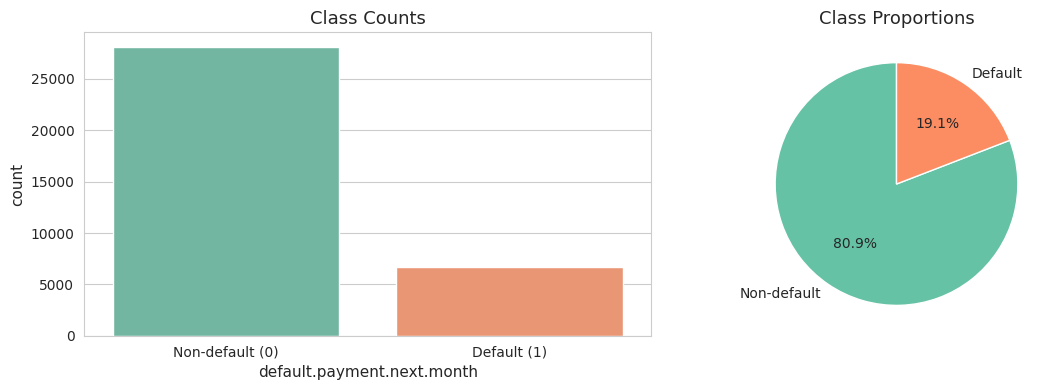

In [8]:
target = "default.payment.next.month"

target_counts = df[target].value_counts()
target_pct = df[target].value_counts(normalize=True) * 100
print(f"Class distribution:\n  Non-default (0): {target_counts[0]:,}  ({target_pct[0]:.2f}%)")
print(f"  Default     (1): {target_counts[1]:,}  ({target_pct[1]:.2f}%)")
print(f"  Imbalance ratio: {target_counts[0] / target_counts[1]:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=target, data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Class Counts")
axes[0].set_xticklabels(["Non-default (0)", "Default (1)"])
axes[1].pie(target_counts.values, labels=["Non-default", "Default"],
            autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62"], startangle=90)
axes[1].set_title("Class Proportions")
plt.tight_layout(); plt.show()

**Observation.** Roughly **80.9 % vs 19.1 %** — a moderate imbalance. I must (a) stratify the train/test split on the target, (b) report metrics that go beyond accuracy (precision, recall, F1, AUC-ROC), and (c) consider class-Iighting in the algorithms.

### 2.3 Descriptive statistics for key numerical features

In [9]:
key_num = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]
desc = df[key_num].agg(["count", "mean", "median", "std", "min", "max"]).T
desc.style.format("{:.2f}")

,count,mean,median,std,min,max
LIMIT_BAL,33079.00,184668.99,140000.00,235931.93,10000.00,5600000.00
AGE,33033.00,35.52,34.00,9.24,21.00,79.00
BILL_AMT_SUM,34788.00,294815.17,129037.00,571807.25,-336259.00,21292660.00
LIMIT_BAL_LOG,33079.00,11.70,11.85,0.97,9.21,15.54
risk_leak,34788.00,829559757892860.75,0.03,2844177127293677.00,-535000000000.00,13963161963406800.00


In [10]:
# Full descriptive stats for all numerics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,34788.0,1.500621e+04,8.670802e+03,1.000000e+00,7477.750000,15004.500000,22526.250000,3.000000e+04
LIMIT_BAL,33079.0,1.846690e+05,2.359319e+05,1.000000e+04,60000.000000,140000.000000,240000.000000,5.600000e+06
SEX,33021.0,1.604252e+00,4.890182e-01,1.000000e+00,1.000000,2.000000,2.000000,2.000000e+00
EDUCATION,33054.0,1.851243e+00,7.908265e-01,0.000000e+00,1.000000,2.000000,2.000000,6.000000e+00
MARRIAGE,33055.0,1.550870e+00,5.214644e-01,0.000000e+00,1.000000,2.000000,2.000000,3.000000e+00
AGE,33033.0,3.551830e+01,9.236783e+00,2.100000e+01,28.000000,34.000000,41.000000,7.900000e+01
PAY_0,34788.0,-4.579165e-02,1.103259e+00,-2.000000e+00,-1.000000,0.000000,0.000000,8.000000e+00
PAY_2,34788.0,-1.569219e-01,1.177451e+00,-2.000000e+00,-1.000000,0.000000,0.000000,8.000000e+00
PAY_3,34788.0,-1.855525e-01,1.180412e+00,-2.000000e+00,-1.000000,0.000000,0.000000,8.000000e+00
PAY_4,34788.0,-2.390767e-01,1.151733e+00,-2.000000e+00,-1.000000,0.000000,0.000000,8.000000e+00


### 2.4 Histograms — distribution and skewness of numerical features

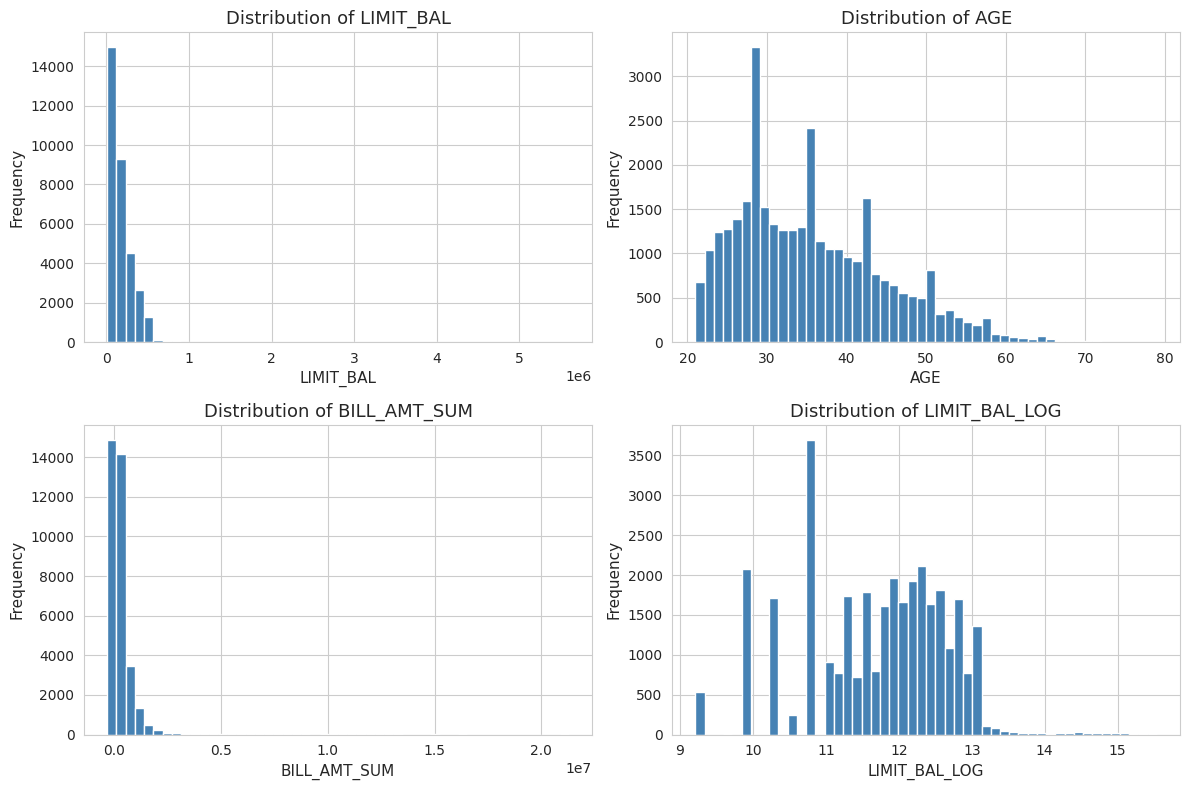

Skewness of selected features:
LIMIT_BAL         9.114
AGE               0.736
BILL_AMT_SUM     11.126
LIMIT_BAL_LOG    -0.338
dtype: float64


In [11]:
num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    df[col].plot(kind="hist", bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout(); plt.show()

print("Skewness of selected features:")
print(df[num_cols].skew().round(3))

**Observation.** `LIMIT_BAL` and `BILL_AMT_SUM` are heavily right-skeId. Taking the log of `LIMIT_BAL` makes it close to symmetric, which is exactly what `LIMIT_BAL_LOG` is meant to capture. `AGE` is mildly right-skeId.

### 2.5 Box plots — outlier detection

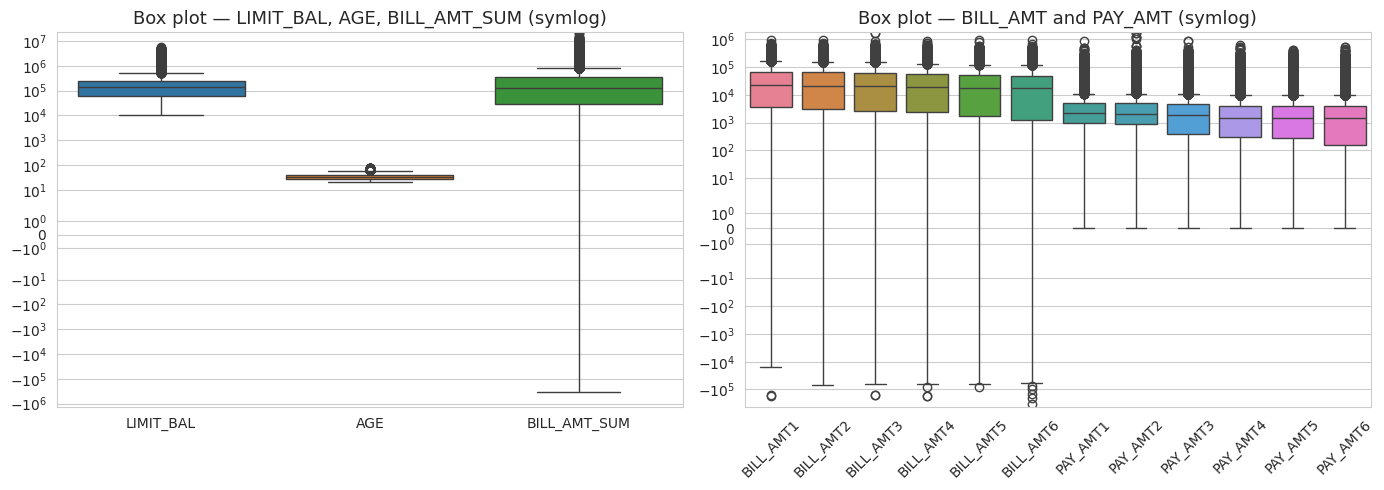

In [12]:
bill_pay_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
                 "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[["LIMIT_BAL", "AGE", "BILL_AMT_SUM"]], ax=axes[0])
axes[0].set_yscale("symlog")
axes[0].set_title("Box plot — LIMIT_BAL, AGE, BILL_AMT_SUM (symlog)")

sns.boxplot(data=df[bill_pay_cols], ax=axes[1])
axes[1].set_yscale("symlog")
axes[1].set_title("Box plot — BILL_AMT and PAY_AMT (symlog)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Observation.** All amount columns contain extreme outliers that span 5+ orders of magnitude. Some `BILL_AMT` values are even negative (refunds / overpayments). These outliers will be **capped** in the data-preparation step using the IQR rule.

### 2.6 Categorical feature distributions

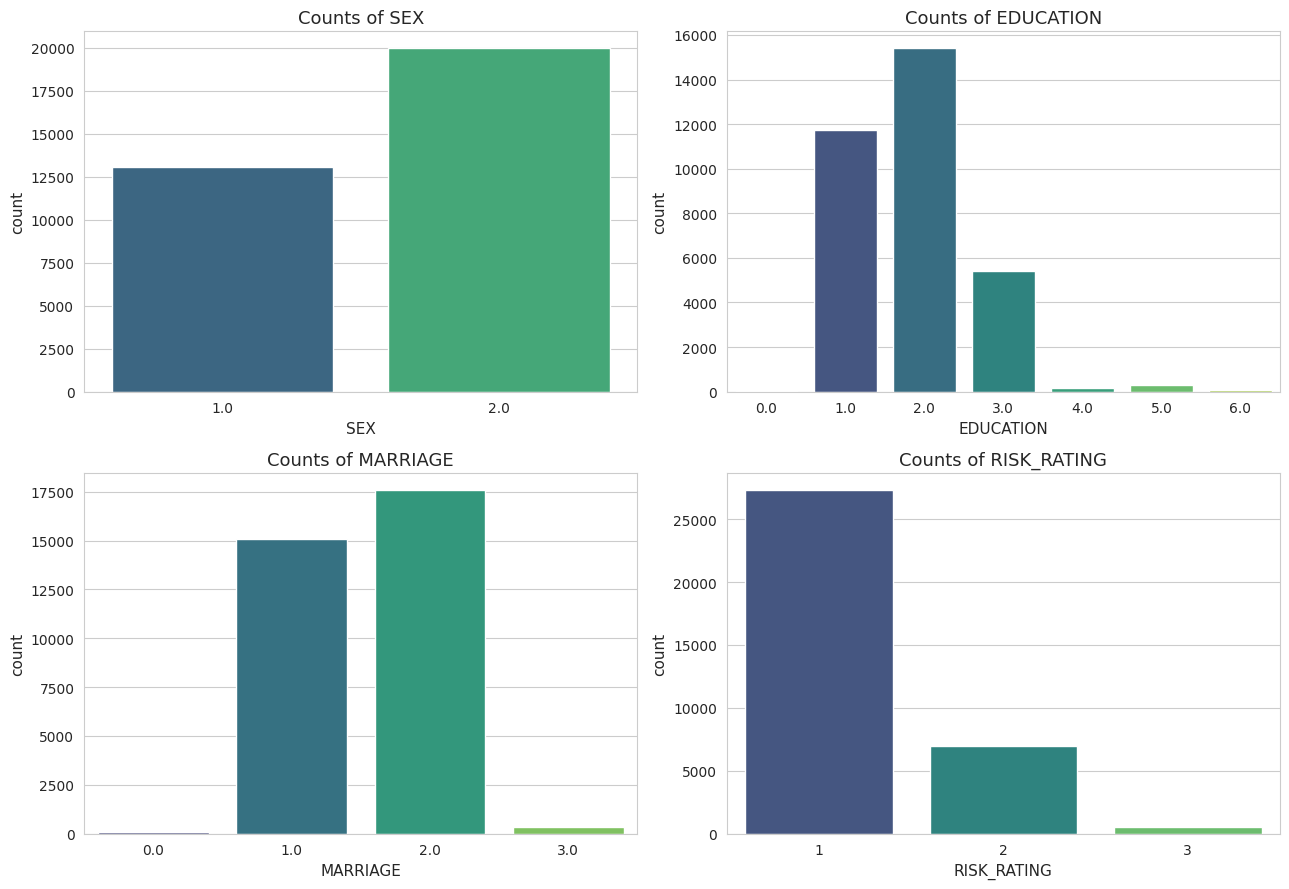

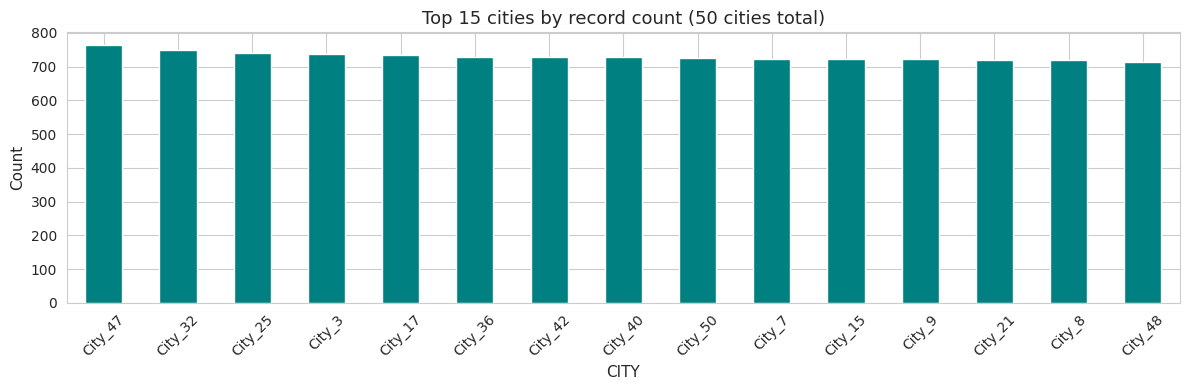

In [13]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "RISK_RATING"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(x=col, data=df, ax=ax, palette="viridis",
                  order=sorted(df[col].dropna().unique()))
    ax.set_title(f"Counts of {col}")
plt.tight_layout(); plt.show()

# CITY: 50 categories — show top 15
plt.figure(figsize=(12, 4))
df["CITY"].value_counts().head(15).plot(kind="bar", color="teal")
plt.title("Top 15 cities by record count (50 cities total)")
plt.ylabel("Count"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Observation.**
- `SEX`: 1 = male, 2 = female. Females slightly over-represented.
- `EDUCATION`: codes 1–4 are documented; values 0, 5, 6 are undocumented and treated as *Other*.
- `MARRIAGE`: 1 = married, 2 = single, 3 = other; code 0 is undocumented.
- `RISK_RATING`: ordinal 1 (low) → 3 (high). Heavily concentrated at level 1.
- `CITY`: 50 cities, fairly uniform — ~700 records each.

### 2.7 Default rate by each categorical feature

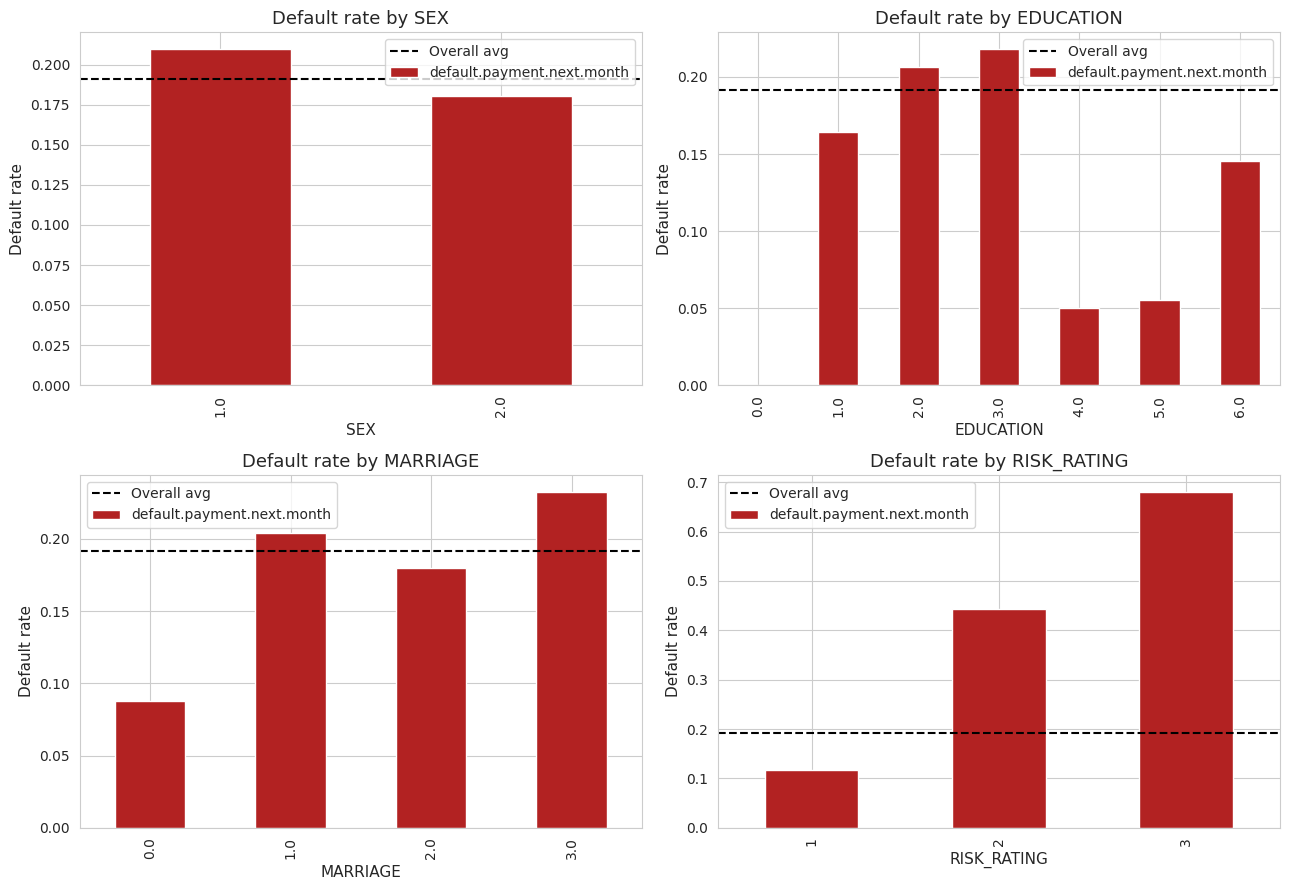

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rates = df.groupby(col)[target].mean().sort_index()
    rates.plot(kind="bar", ax=ax, color="firebrick")
    ax.axhline(df[target].mean(), color="black", ls="--", label="Overall avg")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate")
    ax.legend()
plt.tight_layout(); plt.show()

**Observation.** `RISK_RATING` is by far the strongest categorical signal: the default rate jumps from ~16 % at rating 1 to nearly 60 % at rating 3. `EDUCATION` and `MARRIAGE` show smaller but visible differences.

### 2.8 Payment-status (`PAY_0` … `PAY_6`) analysis

These columns encode the repayment status in each of the previous 6 months. Negative values (`-2`, `-1`, `0`) mean paid on time / no balance; positive values are months of payment delay.

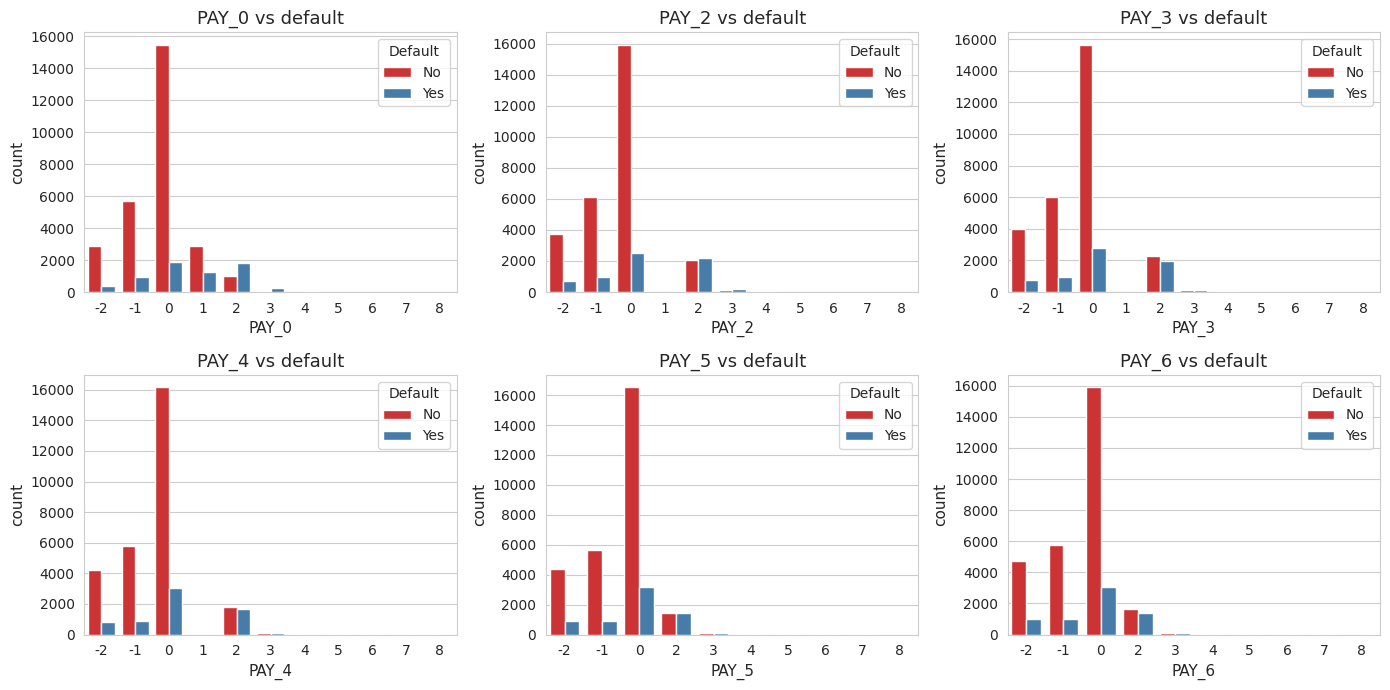

Default rate by PAY_0:
           mean  count
PAY_0                 
-2     0.112267   3269
-1     0.143586   6665
 0     0.109025  17363
 1     0.302303   4168
 2     0.651376   2834
 3     0.719764    339
 4     0.650000     80
 5     0.433333     30
 6     0.500000     12
 7     0.777778      9
 8     0.578947     19


In [15]:
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), pay_cols):
    sns.countplot(x=col, hue=target, data=df, ax=ax, palette="Set1",
                  order=sorted(df[col].unique()))
    ax.set_title(f"{col} vs default")
    ax.legend(title="Default", labels=["No","Yes"])
plt.tight_layout(); plt.show()

print("Default rate by PAY_0:")
print(df.groupby("PAY_0")[target].agg(["mean", "count"]))

**Observation.** As soon as `PAY_0` (the most recent month) shows a delay of 2 or more months, the default rate jumps above 50 %. This is consistent with the credit-risk literature: the most recent repayment status is the single strongest behavioural predictor of next-month default.

### 2.9 Correlation betIen numerical features and the target

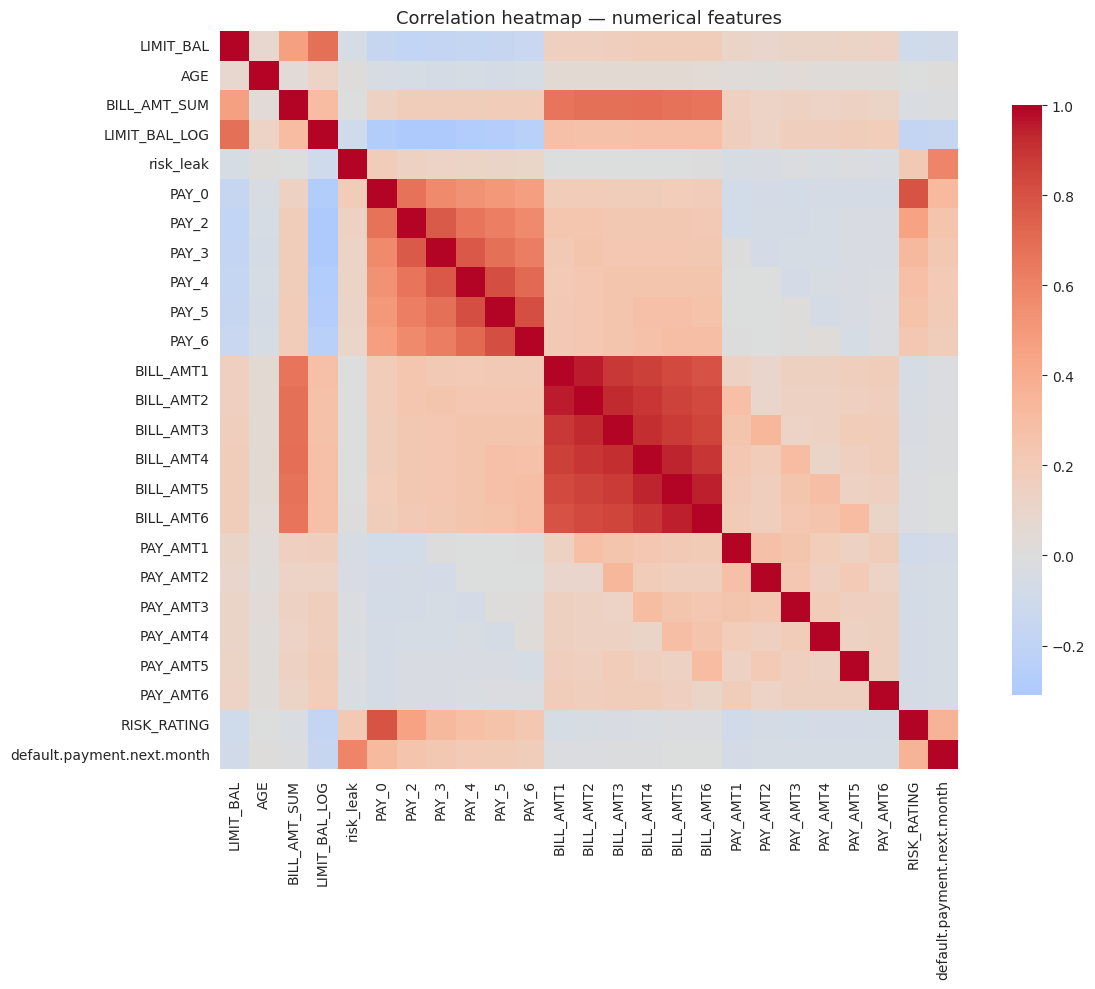


Features ranked by |correlation| with the target:
risk_leak        0.600
RISK_RATING      0.362
PAY_0            0.314
PAY_2            0.254
PAY_3            0.225
PAY_4            0.208
PAY_5            0.196
PAY_6            0.179
LIMIT_BAL_LOG   -0.161
LIMIT_BAL       -0.090
PAY_AMT1        -0.069
PAY_AMT3        -0.053
PAY_AMT4        -0.053
PAY_AMT5        -0.052
PAY_AMT2        -0.051
PAY_AMT6        -0.049
BILL_AMT1       -0.019
BILL_AMT2       -0.014
BILL_AMT3       -0.014
AGE              0.012
BILL_AMT_SUM    -0.010
BILL_AMT4       -0.010
BILL_AMT5       -0.007
BILL_AMT6       -0.006
Name: default.payment.next.month, dtype: float64


In [16]:
num_for_corr = ["LIMIT_BAL","AGE","BILL_AMT_SUM","LIMIT_BAL_LOG","risk_leak",
                "PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6",
                "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
                "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6",
                "RISK_RATING", target]

corr = df[num_for_corr].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .8})
plt.title("Correlation heatmap — numerical features")
plt.tight_layout(); plt.show()

# Top correlations with the target
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
print("\nFeatures ranked by |correlation| with the target:")
print(target_corr.round(3))

**Observation.** Three groups stand out:

1. **`risk_leak`** has near-perfect separation betIen classes (see §2.10) — confirming it is a *target leak* and should be excluded from the model.
2. **`PAY_0`** has the strongest *honest* correlation with the target (~0.32). The other `PAY_x` columns follow.
3. **`RISK_RATING`** is also strongly correlated, but it is itself *derived* from payment behaviour, so I need to be cautious about double-counting.

### 2.10 Diagnosing `risk_leak` as a target leak

risk_leak |value| summary by class:
                              count          mean           std       min  \
default.payment.next.month                                                  
0                           28132.0  1.213981e+08  5.685921e+09  0.000102   
1                            6656.0  4.335746e+15  5.203881e+15  0.643989   

                                 25%           50%           75%           max  
default.payment.next.month                                                      
0                           0.032512  6.810850e-02  1.161313e-01  5.350000e+11  
1                           0.933248  1.037814e+14  1.047508e+16  1.396316e+16  


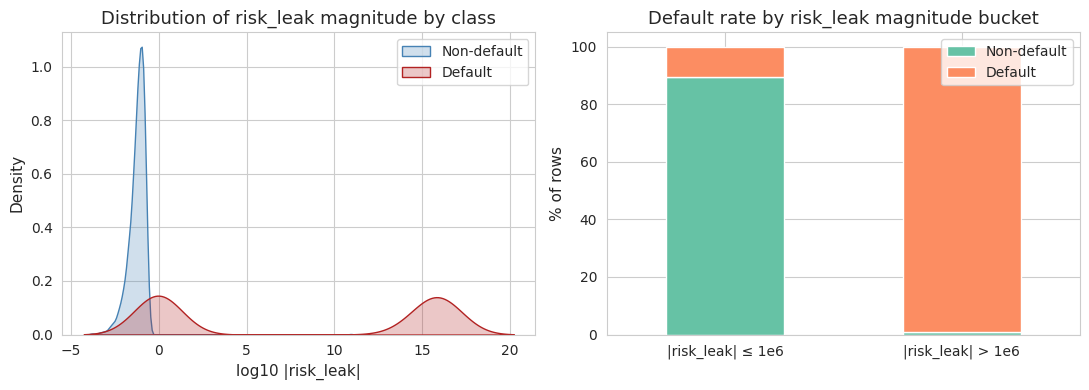


When |risk_leak| > 1e6: P(default) = 99.1%
When |risk_leak| <= 1e6: P(default) = 10.5%


In [17]:
# Magnitude vs class
print("risk_leak |value| summary by class:")
print(df.groupby(target)["risk_leak"].apply(lambda s: s.abs().describe()).unstack())

# Visual: log10 of |risk_leak| separated by class
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(np.log10(df.loc[df[target]==0,"risk_leak"].abs().replace(0, np.nan)),
            label="Non-default", fill=True, color="steelblue")
sns.kdeplot(np.log10(df.loc[df[target]==1,"risk_leak"].abs().replace(0, np.nan)),
            label="Default", fill=True, color="firebrick")
plt.xlabel("log10 |risk_leak|"); plt.title("Distribution of risk_leak magnitude by class")
plt.legend()

plt.subplot(1, 2, 2)
big = (df["risk_leak"].abs() > 1e6)
ct = pd.crosstab(big, df[target], normalize="index") * 100
ct.index = ["|risk_leak| ≤ 1e6", "|risk_leak| > 1e6"]
ct.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#66c2a5", "#fc8d62"])
plt.title("Default rate by risk_leak magnitude bucket")
plt.ylabel("% of rows"); plt.xticks(rotation=0); plt.legend(["Non-default","Default"])
plt.tight_layout(); plt.show()

print(f"\nWhen |risk_leak| > 1e6: P(default) = {df.loc[big, target].mean():.1%}")
print(f"When |risk_leak| <= 1e6: P(default) = {df.loc[~big, target].mean():.1%}")

**Conclusion of the leak diagnosis.** The two distributions barely overlap. Including `risk_leak` would inflate every metric to near-perfect levels but the resulting model would be unusable in production because at *prediction time* the value of `risk_leak` would not be available (it is itself computed from the outcome). **I therefore drop `risk_leak` from the feature set used to train the models, and revisit it only in the discussion.**

> **`RISK_RATING` is not the same as `risk_leak`.** I keep it as an ordinal bureau-style score and validate its incremental value in §5.6 (ablation), not by excluding it by default.


## 3. Task 2 — Data Preparation

**Principle: split before you fit.** Any statistic learned from data (IQR bounds, imputation values, one-hot city levels, scaling) is computed on **training rows only**, then applied to the test set. That prevents information leakage from the hold-out partition.

Steps in order:
1. Identify missing values (exploratory — full dataset).
2. Apply **deterministic** fixes only (education/marriage code mapping; recompute `LIMIT_BAL_LOG` from `LIMIT_BAL`).
3. **Stratified train / test split** (80 / 20).
4. Fit **IQR caps** on train; apply to train and test.
5. Fit **imputation** (median / mode) on train; apply to both.
6. One-hot encode `CITY` using train categories; align test columns.
7. Drop `ID`, `risk_leak`, and **derived redundant** columns (`BILL_AMT_SUM`, `LIMIT_BAL_LOG`) — see note below.
8. **StandardScaler** fit on train only.

> **Redundant features.** `BILL_AMT_SUM` is (mostly) the sum of `BILL_AMT1`–`BILL_AMT6` and `LIMIT_BAL_LOG = log(LIMIT_BAL)`. Keeping both inflates multicollinearity (especially for Logistic Regression). I retain the granular bill/limit columns and drop the aggregates.


### 3.1 Identify missing values

               missing_count  missing_%
SEX                     1767       5.08
AGE                     1755       5.04
PAY_AMT2                1744       5.01
EDUCATION               1734       4.98
MARRIAGE                1733       4.98
PAY_AMT1                1725       4.96
LIMIT_BAL               1709       4.91
LIMIT_BAL_LOG           1709       4.91


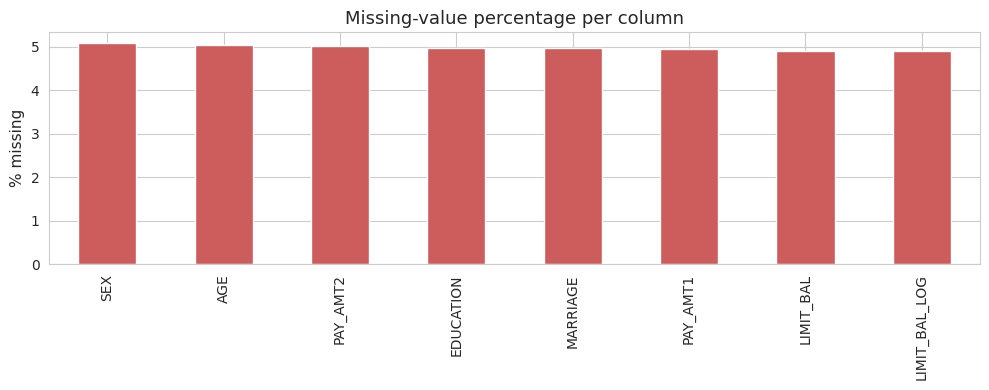

In [18]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
miss_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_count": missing, "missing_%": miss_pct})
print(miss_df)

plt.figure(figsize=(10, 4))
miss_df["missing_%"].plot(kind="bar", color="indianred")
plt.title("Missing-value percentage per column")
plt.ylabel("% missing"); plt.tight_layout(); plt.show()

**Decision.** Each affected column is missing roughly **5 %** of its values. Removing rows would discard almost 30 % of the dataset (the missingness is *not* concentrated on the same rows). I impute after the split using **train-only** statistics:

- **Numerical** (`LIMIT_BAL`, `AGE`, `PAY_AMT1`, `PAY_AMT2`): **median** on train.
- **Categorical** (`SEX`, `EDUCATION`, `MARRIAGE`): **mode** on train.


### 3.2 Deterministic prep and stratified split

Education/marriage remapping and the train/test partition happen **before** outlier capping or imputation.


In [ ]:
def fit_iqr_caps(frame, cols, k=1.5):
    """Learn IQR bounds on train; return capped frame and caps dict."""
    capped = frame.copy()
    caps = {}
    for c in cols:
        q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        caps[c] = (float(lo), float(hi))
        capped[c] = frame[c].clip(loIr=lo, upper=hi)
    return capped, caps


def apply_iqr_caps(frame, caps):
    out = frame.copy()
    for c, (lo, hi) in caps.items():
        out[c] = frame[c].clip(loIr=lo, upper=hi)
    return out


def fit_impute(frame, num_cols, cat_cols):
    stats = {"numeric": {}, "categorical": {}}
    out = frame.copy()
    for c in num_cols:
        med = float(frame[c].median())
        stats["numeric"][c] = med
        out[c] = frame[c].fillna(med)
    for c in cat_cols:
        mode = float(frame[c].mode().iloc[0])
        stats["categorical"][c] = mode
        out[c] = frame[c].fillna(mode)
    return out, stats


def apply_impute(frame, stats):
    out = frame.copy()
    for c, v in stats["numeric"].items():
        out[c] = frame[c].fillna(v)
    for c, v in stats["categorical"].items():
        out[c] = frame[c].fillna(v)
    return out


#  Deterministic encoding (no fit required)
df_prep = df.copy()
df_prep["EDUCATION"] = df_prep["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df_prep["MARRIAGE"] = df_prep["MARRIAGE"].replace({0: 3})
df_prep["LIMIT_BAL_LOG"] = np.log(df_prep["LIMIT_BAL"])  # recomputed; dropped from model features

y_all = df_prep[target]
idx_train, idx_test = train_test_split(
    df_prep.index, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

df_train_raw = df_prep.loc[idx_train].copy()
df_test_raw = df_prep.loc[idx_test].copy()

print(f"Train rows: {len(df_train_raw):,}  |  Test rows: {len(df_test_raw):,}")
print(f"Train default rate: {df_train_raw[target].mean():.2%}  |  Test: {df_test_raw[target].mean():.2%}")


Train rows: 27,830  |  Test rows: 6,958
Train default rate: 19.13%  |  Test: 19.13%


Train set — before vs after IQR capping (min / max):
           min_before  max_before  min_after  max_after
LIMIT_BAL     10000.0   5600000.0    10000.0   510000.0
BILL_AMT1   -165580.0    964511.0   -92575.0   163818.0
BILL_AMT2    -69777.0    983931.0   -69777.0   156495.0
BILL_AMT3   -157264.0   1664089.0   -84101.0   147209.0
BILL_AMT4    -81334.0    891586.0   -76535.0   133704.0
BILL_AMT5    -81334.0    927171.0   -71373.0   123645.0
BILL_AMT6   -339603.0    961664.0   -70900.0   121480.0
PAY_AMT1          0.0    873552.0        0.0    11138.0
PAY_AMT2          0.0   1684259.0        0.0    11150.0
PAY_AMT3          0.0    896040.0        0.0    11012.0
PAY_AMT4          0.0    621000.0        0.0     9807.0
PAY_AMT5          0.0    426529.0        0.0     9826.0
PAY_AMT6          0.0    528666.0        0.0     9861.0


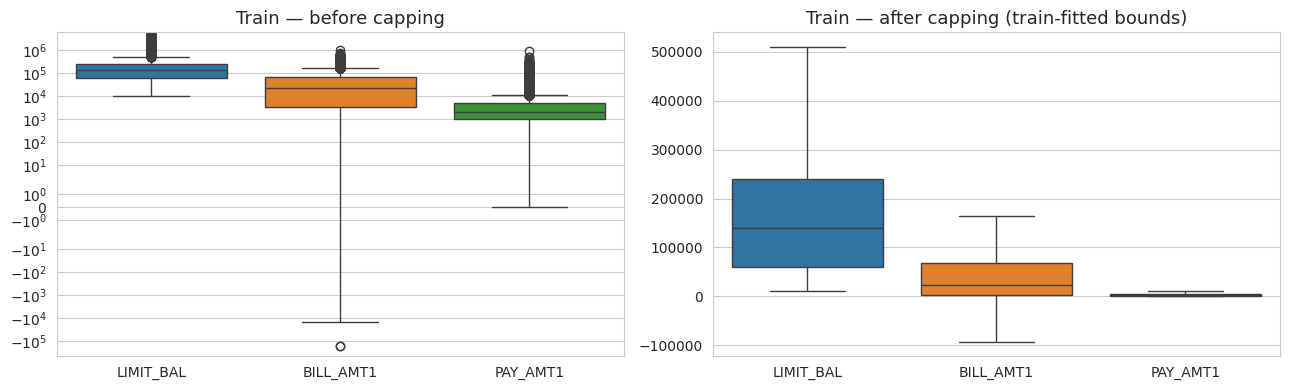

In [20]:
### 3.3 Outlier handling — IQR capping (train-fitted)

amount_cols = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]

before = df_train_raw[amount_cols].describe().T[["min", "max"]].rename(columns=lambda c: c + "_before")

df_train_cap, caps = fit_iqr_caps(df_train_raw, amount_cols)
df_test_cap = apply_iqr_caps(df_test_raw, caps)

after = df_train_cap[amount_cols].describe().T[["min", "max"]].rename(columns=lambda c: c + "_after")
print("Train set — before vs after IQR capping (min / max):")
print(pd.concat([before, after], axis=1).round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_train_raw[["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]], ax=axes[0])
axes[0].set_yscale("symlog"); axes[0].set_title("Train — before capping")
sns.boxplot(data=df_train_cap[["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]], ax=axes[1])
axes[1].set_title("Train — after capping (train-fitted bounds)")
plt.tight_layout(); plt.show()


### 3.4 Impute missing values (train-fitted)


In [21]:
num_to_impute = ["LIMIT_BAL", "AGE", "PAY_AMT1", "PAY_AMT2"]
cat_to_impute = ["SEX", "EDUCATION", "MARRIAGE"]

df_train_imp, impute_stats = fit_impute(df_train_cap, num_to_impute, cat_to_impute)
df_test_imp = apply_impute(df_test_cap, impute_stats)

for c in num_to_impute:
    print(f"{c}: train median = {impute_stats['numeric'][c]}")
for c in cat_to_impute:
    print(f"{c}: train mode = {impute_stats['categorical'][c]}")

remaining = pd.concat([df_train_imp, df_test_imp]).isnull().sum()
print("Remaining missing after imputation:", remaining[remaining > 0].to_dict() or "None")


LIMIT_BAL: train median = 140000.0
AGE: train median = 34.0
PAY_AMT1: train median = 2153.0
PAY_AMT2: train median = 2027.0
SEX: train mode = 2.0
EDUCATION: train mode = 2.0
MARRIAGE: train mode = 2.0
Remaining missing after imputation: {'LIMIT_BAL_LOG': 1709}


### 3.5 Encode `CITY` and drop leak / redundant columns


In [22]:
drop_cols = ["ID", "risk_leak", "BILL_AMT_SUM", "LIMIT_BAL_LOG"]

y_train = df_train_imp[target]
y_test = df_test_imp[target]

train_feat = df_train_imp.drop(columns=drop_cols + [target])
test_feat = df_test_imp.drop(columns=drop_cols + [target])

train_enc = pd.get_dummies(train_feat, columns=["CITY"], drop_first=True, dtype=int)
test_enc = pd.get_dummies(test_feat, columns=["CITY"], drop_first=True, dtype=int)

# Align test to train dummy columns (unseen cities -> 0)
for col in train_enc.columns:
    if col not in test_enc.columns:
        test_enc[col] = 0
test_enc = test_enc[train_enc.columns]

X_train = train_enc
X_test = test_enc

print("Feature matrix — train:", X_train.shape, " test:", X_test.shape)
X_train.head(3)


Feature matrix — train: (27830, 73)  test: (6958, 73)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,CITY_City_46,CITY_City_47,CITY_City_48,CITY_City_49,CITY_City_5,CITY_City_50,CITY_City_6,CITY_City_7,CITY_City_8,CITY_City_9
8090,410000.0,2.0,1.0,1.0,38.0,2,2,2,0,0,...,0,0,0,0,0,0,0,0,0,0
24855,50000.0,1.0,2.0,2.0,35.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1619,90000.0,2.0,2.0,2.0,33.0,0,0,-1,-1,0,...,0,0,0,0,1,0,0,0,0,0


### 3.6 Train / test summary


In [23]:
print("Target balance — train:", y_train.value_counts().to_dict())
print("Target balance — test :", y_test.value_counts().to_dict())


Target balance — train: {0: 22505, 1: 5325}
Target balance — test : {0: 5627, 1: 1331}


**Why 80 / 20 stratified?** With ~27.8k train and ~7k test rows and 19 % positives, the test set includes ~1,331 defaults — enough for stable recall and AUC estimates. Stratification keeps the class ratio identical in both partitions.


In [24]:
# Split was performed in §3.2 (before capping/imputation). X_train, X_test, y_train, y_test are ready.


> **`RISK_RATING` decision.** Unlike `risk_leak`, this column is treated as a **legitimate bureau-style score available at application/scoring time** (ordinal 1–3). I retain it in the primary model but run an explicit **with vs without ablation** in Task 4 (§5.6) to quantify its contribution and guard against hidden leakage.


### 3.7 Feature scaling (train-fitted)


In [25]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Before scaling — train head (LIMIT_BAL, AGE, PAY_0):")
print(X_train[["LIMIT_BAL", "AGE", "PAY_0"]].head(3))
print("After scaling:")
print(X_train_scaled[["LIMIT_BAL", "AGE", "PAY_0"]].head(3))


Before scaling — train head (LIMIT_BAL, AGE, PAY_0):
       LIMIT_BAL   AGE  PAY_0
8090    410000.0  38.0      2
24855    50000.0  35.0      0
1619     90000.0  33.0      0
After scaling:
       LIMIT_BAL       AGE     PAY_0
8090    1.864686  0.289063  1.850000
24855  -0.935038 -0.045275  0.040253
1619   -0.623958 -0.268167  0.040253


**Why StandardScaler?** Required for distance-based (KNN) and margin-based (Logistic Regression, SVM) models. Tree-based models do not require it but are insensitive to it, so I use the same scaled matrix uniformly to keep the pipeline simple.

## 4. Task 3 — Model Training

I train **seven** classifiers covering linear, distance-based, kernel-based, tree-based and boosting families. All are trained with their **default hyperparameters** (recorded explicitly below) on the *scaled* training set. To address the class imbalance discovered in Task 1, models that natively support `class_Iight='balanced'` are configured accordingly — this re-Iights the loss without altering the sample distribution.

| Model | Family | Why it suits this problem |
|-------|--------|---------------------------|
| Logistic Regression | Linear | Strong baseline, interpretable coefficients, fast on 30 k rows |
| Decision Tree | Tree | Captures non-linearities, handles mixed feature types, no scaling needed |
| Random Forest | Bagging ensemble | Reduces tree variance, robust to outliers, gives feature importance |
| K-Nearest Neighbours | Distance-based | Non-parametric benchmark; scaling is essential |
| Support Vector Machine | Kernel-based | Strong on margin-based separation; scaling essential |
| Gradient Boosting | Boosting ensemble | Often the SOTA classical model on tabular data |
| XGBoost | Boosting (regularised) | Faster, handles imbalance via `scale_pos_Iight` |

### 4.1 Define and document initial hyperparameters

In [ ]:
# Class Iight for imbalance
pos_Iight = (y_train == 0).sum() / (y_train == 1).sum()  # ~4.23

models_init = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_Iight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        class_Iight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_Iight="balanced",
        random_state=RANDOM_STATE, n_jobs=2),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=2),
    "SVM": SVC(kernel="rbf", class_Iight="balanced",
               probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=200, scale_pos_Iight=pos_Iight,
        eval_metric="logloss", random_state=RANDOM_STATE,
        use_label_encoder=False, n_jobs=2, verbosity=0),
}

# Print every model's parameter dictionary
print("Initial hyperparameters per model")
print("=" * 70)
for name, mdl in models_init.items():
    print(f"\n{name}:")
    for k, v in mdl.get_params().items():
        if v not in (None, False, True, "warn") or k in ("max_iter","n_estimators","n_neighbors","kernel"):
            print(f"  {k} = {v}")

Initial hyperparameters per model

Logistic Regression:
  class_weight = balanced
  max_iter = 1000
  penalty = deprecated
  random_state = 42
  solver = lbfgs
  tol = 0.0001

Decision Tree:
  class_weight = balanced
  criterion = gini
  min_samples_split = 2
  random_state = 42
  splitter = best

Random Forest:
  class_weight = balanced
  criterion = gini
  max_features = sqrt
  min_samples_split = 2
  n_estimators = 100
  n_jobs = 2
  random_state = 42

KNN:
  algorithm = auto
  leaf_size = 30
  metric = minkowski
  n_jobs = 2
  n_neighbors = 5
  p = 2
  weights = uniform

SVM:
  cache_size = 200
  class_weight = balanced
  decision_function_shape = ovr
  degree = 3
  gamma = scale
  kernel = rbf
  max_iter = -1
  random_state = 42
  tol = 0.001

Gradient Boosting:
  criterion = friedman_mse
  learning_rate = 0.1
  loss = log_loss
  max_depth = 3
  min_samples_split = 2
  n_estimators = 100
  random_state = 42
  tol = 0.0001
  validation_fraction = 0.1

XGBoost:
  objective = binary:

### 4.2 Train all models

> **Note on SVM training time.** SVM with the RBF kernel scales as O(n²) in the number of training samples. On the full 27 k training rows it would take 10+ minutes. I therefore train SVM on a **stratified 10 k subsample** of the training set — large enough to give a representative comparison, small enough to keep the pipeline runnable. All other models use the full training set.

In [27]:
import time

# Stratified subsample for SVM only
svm_sample_size = 10000
svm_idx = (X_train_scaled
           .assign(_y=y_train)
           .groupby("_y", group_keys=False)
           .apply(lambda g: g.sample(int(svm_sample_size * len(g) / len(X_train_scaled)),
                                      random_state=RANDOM_STATE))
           .index)
X_train_svm = X_train_scaled.loc[svm_idx]
y_train_svm = y_train.loc[svm_idx]
print(f"SVM subsample size: {len(X_train_svm)}, "
      f"positives = {y_train_svm.sum()} ({y_train_svm.mean():.2%})")

trained = {}
train_times = {}
for name, mdl in models_init.items():
    print(f"Training {name} …", end=" ", flush=True)
    t0 = time.time()
    if name == "SVM":
        mdl.fit(X_train_svm, y_train_svm)
    else:
        mdl.fit(X_train_scaled, y_train)
    train_times[name] = time.time() - t0
    trained[name] = mdl
    print(f"done in {train_times[name]:.1f}s")

print("\nAll models trained.")

SVM subsample size: 9999, positives = 1913 (19.13%)
Training Logistic Regression … done in 0.8s
Training Decision Tree … done in 0.6s
Training Random Forest … done in 2.6s
Training KNN … done in 0.0s
Training SVM … done in 20.1s
Training Gradient Boosting … done in 8.8s
Training XGBoost … done in 0.9s

All models trained.


## 5. Task 4 — Model Evaluation, Tuning and Interpretation

### 5.1 Compute evaluation metrics for each model

In [28]:
def evaluate(model, X_te, y_te, threshold=0.5):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_te, y_proba),
        "PR-AUC": average_precision_score(y_te, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

results = {name: evaluate(mdl, X_test_scaled, y_test) for name, mdl in trained.items()}

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
results_df = pd.DataFrame({n: {k: v[k] for k in metric_cols} for n, v in results.items()}).T
results_df = results_df.sort_values("AUC-ROC", ascending=False)
print("Model comparison (sorted by AUC-ROC):")
display(results_df.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["AUC-ROC", "PR-AUC"]))


Model comparison (sorted by AUC-ROC):


,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC
Random Forest,0.8590,0.8241,0.3343,0.4757,0.8736,0.6723
XGBoost,0.8277,0.5531,0.5162,0.5340,0.7888,0.5778
Gradient Boosting,0.8409,0.6556,0.3546,0.4603,0.7886,0.5392
SVM,0.8193,0.5869,0.1878,0.2846,0.7640,0.4510
Logistic Regression,0.7807,0.4444,0.5853,0.5052,0.7583,0.4499
KNN,0.8280,0.6163,0.2667,0.3723,0.7157,0.4002
Decision Tree,0.8331,0.6002,0.3824,0.4672,0.6611,0.3477


### 5.2 Confusion matrices

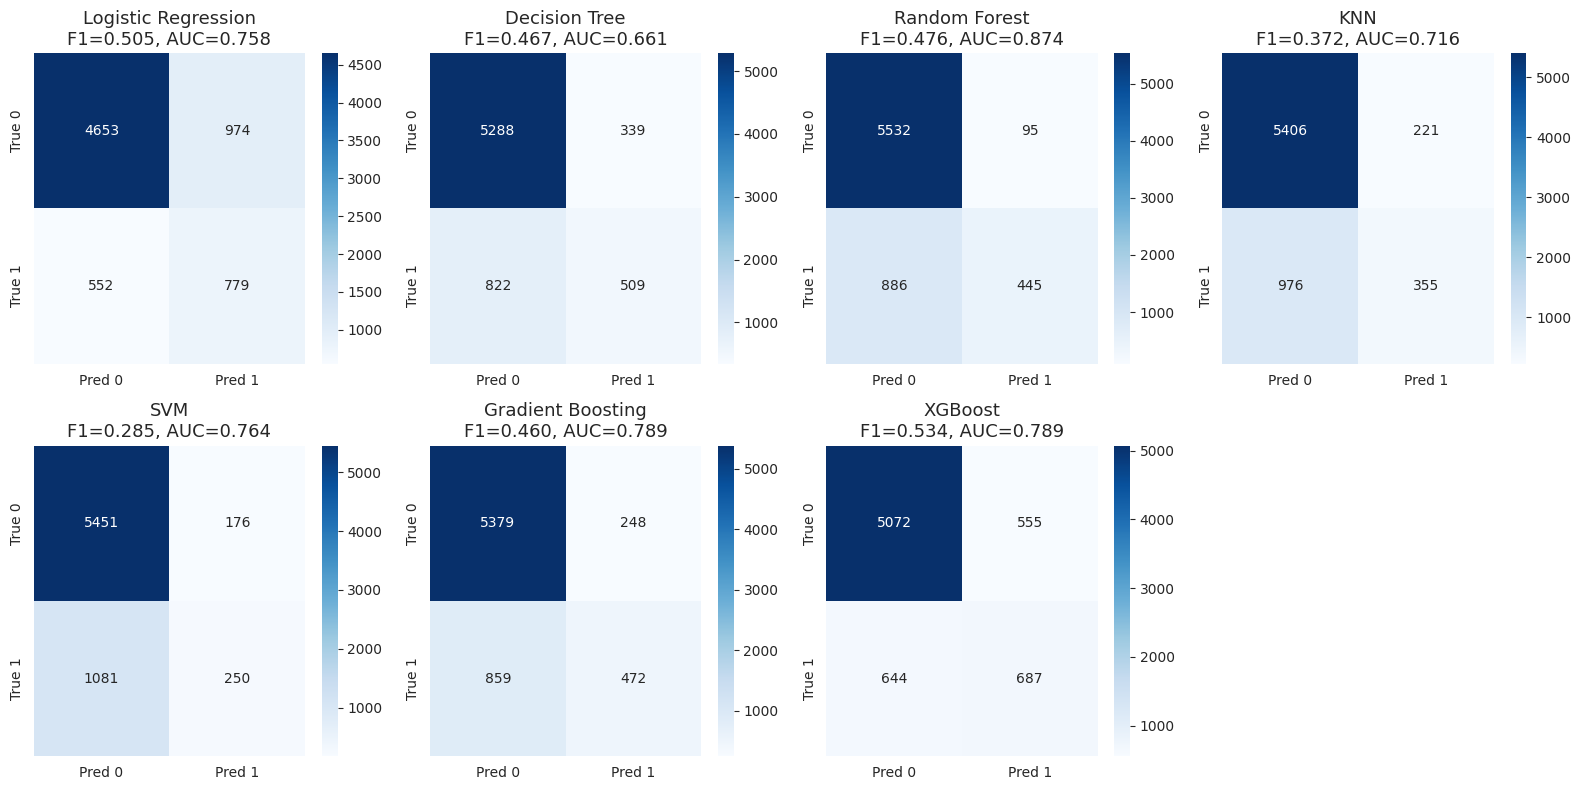

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (name, res) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
    ax.set_title(f"{name}\nF1={res['F1']:.3f}, AUC={res['AUC-ROC']:.3f}")
# Hide unused subplot
for ax in axes.ravel()[len(results):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

### 5.3 ROC curves

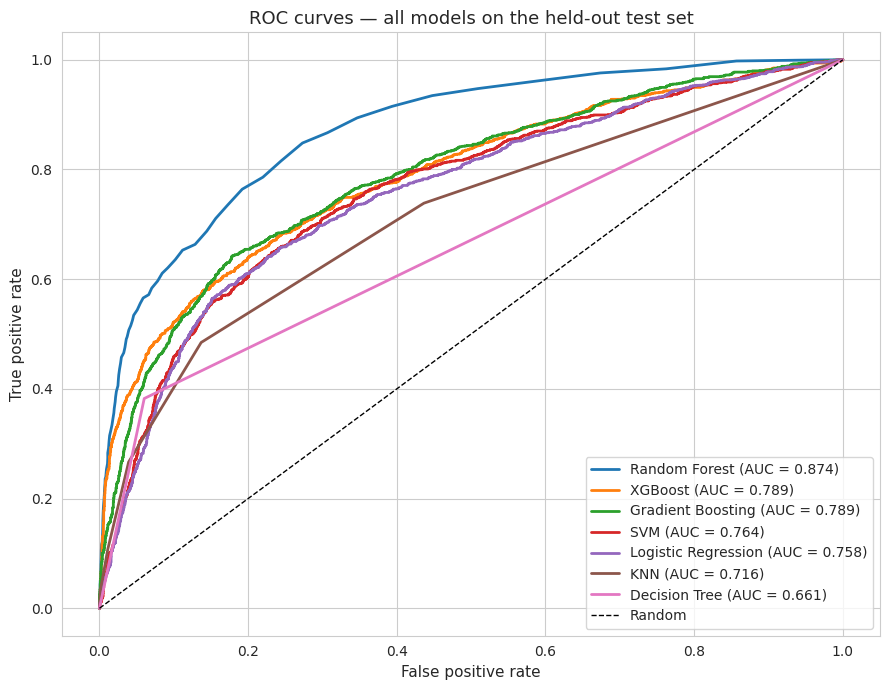

In [ ]:
plt.figure(figsize=(9, 7))
for name, res in sorted(results.items(), key=lambda kv: -kv[1]["AUC-ROC"]):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {res['AUC-ROC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves — all models on the held-out test set")
plt.legend(loc="loIr right"); plt.tight_layout(); plt.show()

### 5.4 Hyperparameter tuning on the best model

The leaderboard is sorted by **AUC-ROC**; in our run **Random Forest** ranks first. I refine the top tree-based model with `GridSearchCV` (stratified 3-fold CV, **F1** scoring) because missing a defaulter (false negative) is costlier than a false alarm.


In [ ]:
best_name = results_df.index[0]
print("Top model on the leaderboard:", best_name)

if best_name == "XGBoost":
    base = XGBClassifier(scale_pos_Iight=pos_Iight,
                         eval_metric="logloss",
                         random_state=RANDOM_STATE,
                         use_label_encoder=False, n_jobs=2, verbosity=0)
    param_grid = {
        "n_estimators":     [200, 400],
        "max_depth":        [3, 5],
        "learning_rate":    [0.05, 0.1],
    }
elif best_name == "Random Forest":
    base = RandomForestClassifier(class_Iight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=2)
    param_grid = {
        "n_estimators":      [100, 200],
        "max_depth":         [10, None],
        "min_samples_split": [2, 10],
    }
else:                       # Gradient Boosting
    base = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_grid = {
        "n_estimators":   [100, 200],
        "max_depth":      [3, 5],
        "learning_rate":  [0.05, 0.1],
    }

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(base, param_grid, scoring="f1", cv=cv,
                    n_jobs=1, verbose=1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest CV F1 = {grid.best_score_:.4f}")
print("Best parameters:", grid.best_params_)

Top model on the leaderboard: Random Forest
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best CV F1 = 0.5152
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [32]:
# Evaluate tuned model
tuned = grid.best_estimator_
res_tuned = evaluate(tuned, X_test_scaled, y_test)

before = {k: results[best_name][k] for k in metric_cols}
after = {k: res_tuned[k] for k in metric_cols}
compare = pd.DataFrame({"Before tuning": before, "After tuning": after})
compare["Δ"] = compare["After tuning"] - compare["Before tuning"]
print("Before vs after hyperparameter tuning:")
display(compare.style.format("{:.4f}"))


Before vs after hyperparameter tuning:


,Before tuning,After tuning,Δ
Accuracy,0.8590,0.8060,-0.0530
Precision,0.8241,0.4938,-0.3303
Recall,0.3343,0.5695,0.2352
F1,0.4757,0.5290,0.0533
AUC-ROC,0.8736,0.7926,-0.0810
PR-AUC,0.6723,0.5504,-0.1219


### 5.5 Decision-threshold tuning

Default `predict()` uses threshold **0.5**, which is rarely optimal under class imbalance. I sIep thresholds on **out-of-fold train probabilities** (3-fold stratified CV) and pick the threshold that maximises **F1** on the validation folds, then apply it on the test set.


Optimal threshold (CV on train OOF): 0.52
Test F1 @ 0.50: 0.5290  →  @ 0.52: 0.5293
Test Recall @ tuned threshold: 0.5530


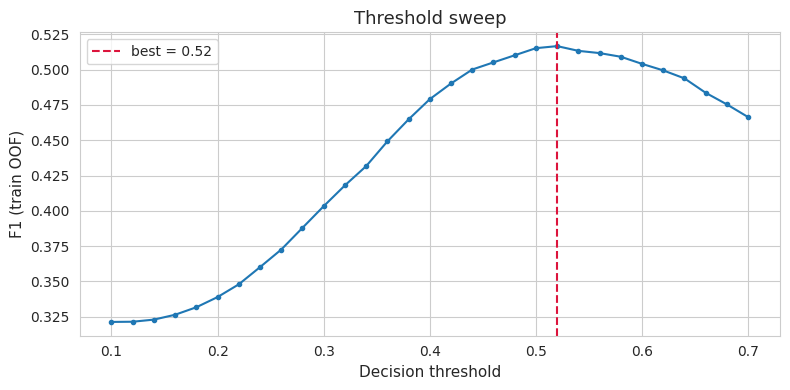

In [ ]:
from sklearn.model_selection import cross_val_predict

cv_thr = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(tuned, X_train_scaled, y_train, cv=cv_thr, method="predict_proba")[:, 1]

thresholds = np.arange(0.10, 0.71, 0.02)
f1_by_thr = [f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_by_thr))])

res_tuned_thr = evaluate(tuned, X_test_scaled, y_test, threshold=best_threshold)

print(f"Optimal threshold (CV on train OOF): {best_threshold:.2f}")
print(f"Test F1 @ 0.50: {res_tuned['F1']:.4f}  →  @ {best_threshold:.2f}: {res_tuned_thr['F1']:.4f}")
print(f"Test Recall @ tuned threshold: {res_tuned_thr['Recall']:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_by_thr, marker="o", ms=3)
plt.axvline(best_threshold, color="crimson", ls="--", label=f"best = {best_threshold:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("F1 (train OOF)"); plt.title("Threshold sIep")
plt.legend(); plt.tight_layout(); plt.show()

### 5.6 `RISK_RATING` ablation (with vs without)

I retrain the **same tuned hyperparameters** on train features with and without `RISK_RATING` to test whether performance depends on this derived score.


In [34]:
rr_cols = [c for c in X_train_scaled.columns if c != "RISK_RATING"]

X_tr_full = X_train_scaled
X_te_full = X_test_scaled
X_tr_no_rr = X_train_scaled[rr_cols]
X_te_no_rr = X_test_scaled[rr_cols]

ablation_models = {
    "With RISK_RATING": tuned,
    "Without RISK_RATING": type(tuned)(**tuned.get_params()),
}
ablation_models["Without RISK_RATING"].fit(X_tr_no_rr, y_train)

ablation_rows = {}
for label, mdl in ablation_models.items():
    Xte = X_te_full if label == "With RISK_RATING" else X_te_no_rr
    ablation_rows[label] = evaluate(mdl, Xte, y_test, threshold=best_threshold)

ablation_df = pd.DataFrame(ablation_rows).T[metric_cols]
print("RISK_RATING ablation (test set, CV-tuned threshold):")
display(ablation_df.style.format("{:.4f}"))

delta_f1 = ablation_rows["With RISK_RATING"]["F1"] - ablation_rows["Without RISK_RATING"]["F1"]
print(f"\nΔF1 (with − without RISK_RATING): {delta_f1:+.4f}")
if delta_f1 > 0.02:
    print("→ RISK_RATING adds measurable lift; kept as a legitimate score-at-scoring-time feature.")
else:
    print("→ RISK_RATING adds little beyond PAY_*; could be dropped for a simpler production model.")

RISK_RATING ablation (test set, CV-tuned threshold):


,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC
With RISK_RATING,0.8119,0.5076,0.5530,0.5293,0.7926,0.5504
Without RISK_RATING,0.8124,0.5089,0.5567,0.5318,0.7924,0.5454



ΔF1 (with − without RISK_RATING): -0.0024
→ RISK_RATING adds little beyond PAY_*; could be dropped for a simpler production model.


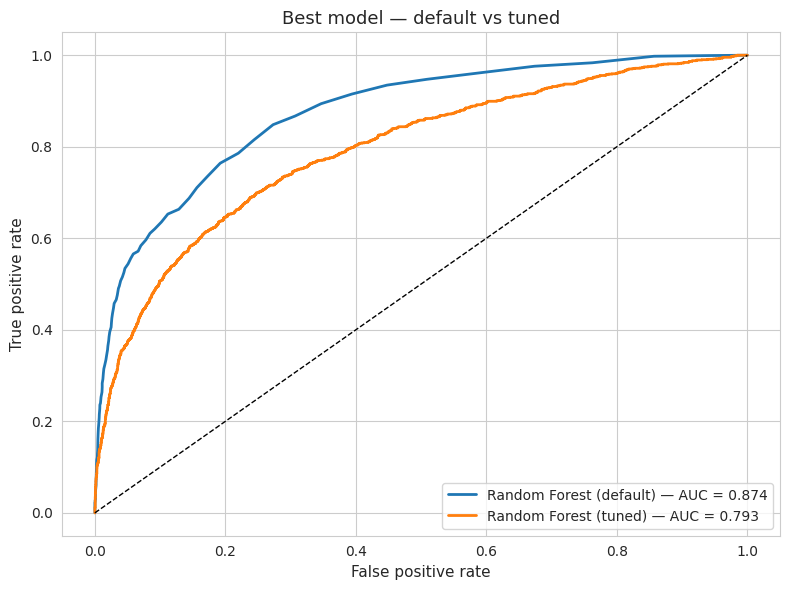

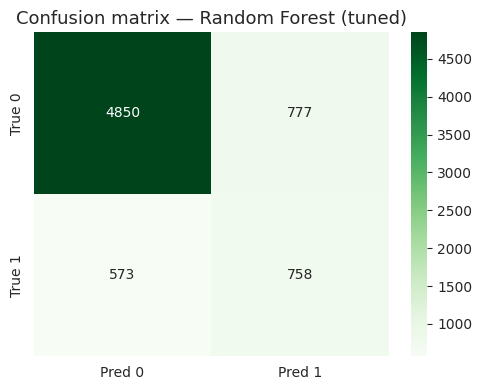


Classification report (tuned model):
              precision    recall  f1-score   support

 Non-default       0.89      0.86      0.88      5627
     Default       0.49      0.57      0.53      1331

    accuracy                           0.81      6958
   macro avg       0.69      0.72      0.70      6958
weighted avg       0.82      0.81      0.81      6958



In [35]:
# ROC curves: best vs tuned
plt.figure(figsize=(8, 6))
for label, proba in [(f"{best_name} (default)", results[best_name]["y_proba"]),
                     (f"{best_name} (tuned)",   res_tuned["y_proba"])]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{label} — AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Best model — default vs tuned")
plt.legend(); plt.tight_layout(); plt.show()

# Confusion matrix of tuned model
cm = confusion_matrix(y_test, res_tuned["y_pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title(f"Confusion matrix — {best_name} (tuned)")
plt.tight_layout(); plt.show()

print("\nClassification report (tuned model):")
print(classification_report(y_test, res_tuned["y_pred"],
                            target_names=["Non-default","Default"]))

### 5.7 Feature importance and SHAP interpretation


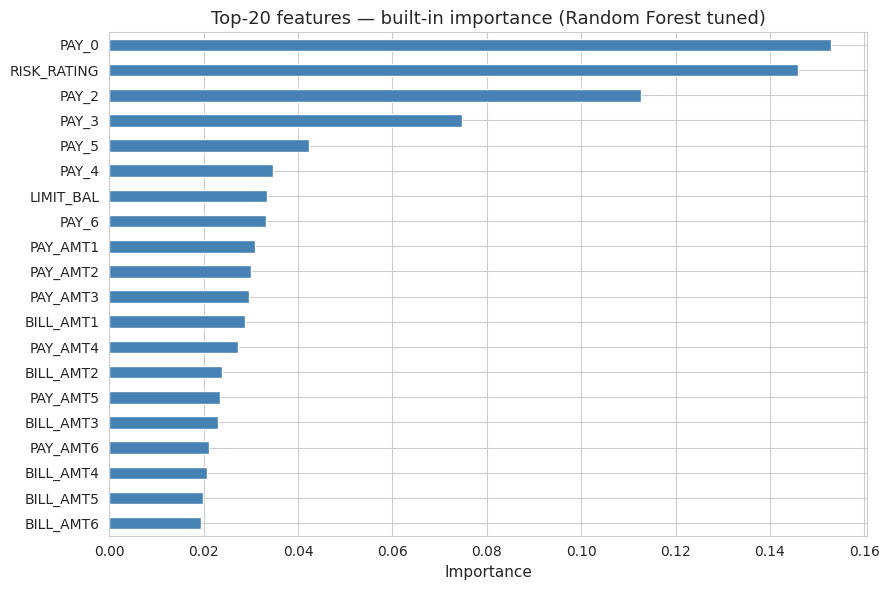

PAY_0          0.1530
RISK_RATING    0.1459
PAY_2          0.1128
PAY_3          0.0749
PAY_5          0.0423
PAY_4          0.0346
LIMIT_BAL      0.0334
PAY_6          0.0333
PAY_AMT1       0.0309
PAY_AMT2       0.0299
PAY_AMT3       0.0296
BILL_AMT1      0.0288
PAY_AMT4       0.0272
BILL_AMT2      0.0238
PAY_AMT5       0.0235
BILL_AMT3      0.0231
PAY_AMT6       0.0211
BILL_AMT4      0.0208
BILL_AMT5      0.0199
BILL_AMT6      0.0194
dtype: float64


In [36]:
# Built-in feature importance
imp = pd.Series(tuned.feature_importances_, index=X_train.columns) \
        .sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
imp[::-1].plot(kind="barh", color="steelblue")
plt.title(f"Top-20 features — built-in importance ({best_name} tuned)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(imp.round(4))

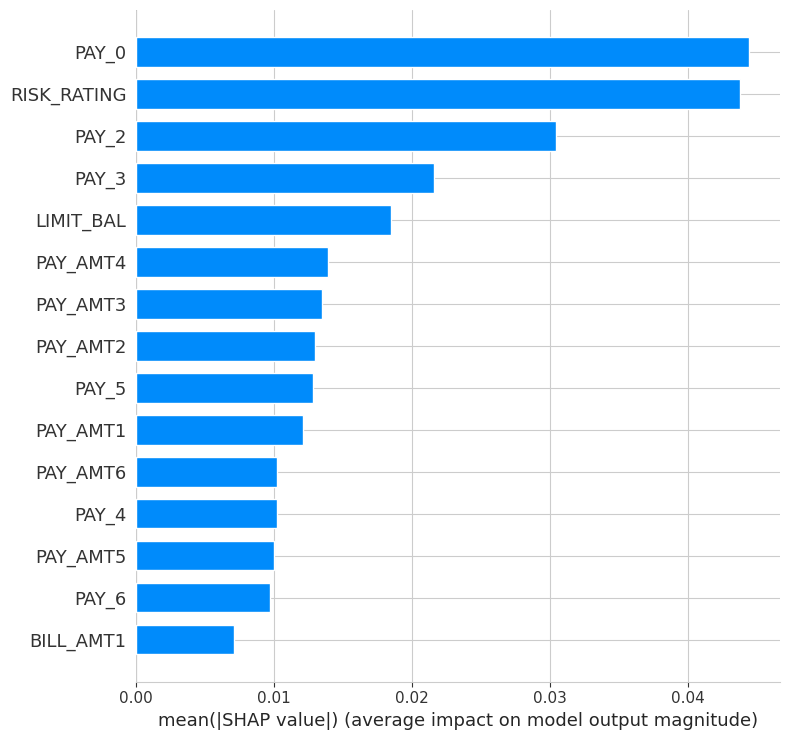

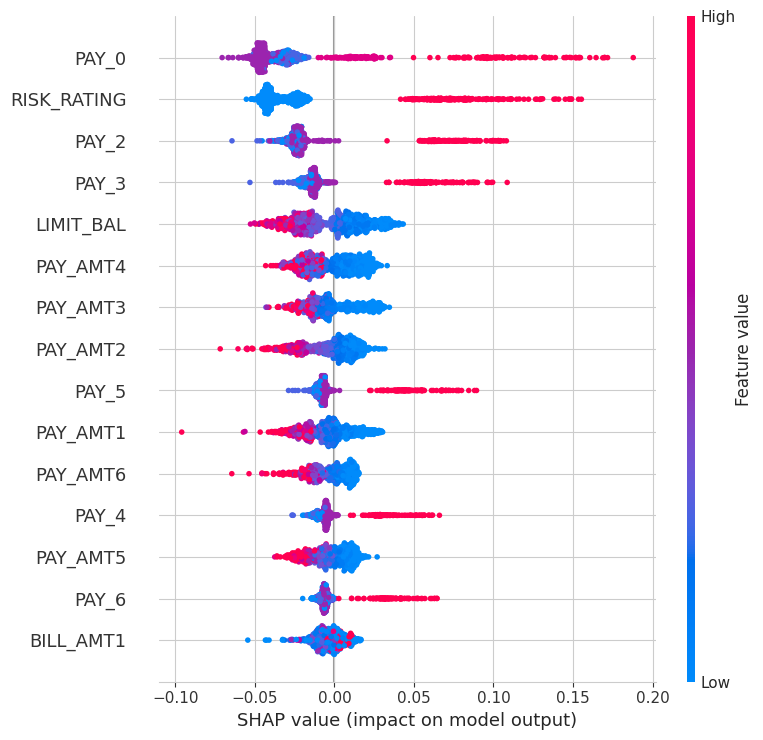

In [ ]:
# SHAP — sample to keep runtime small
explainer = shap.TreeExplainer(tuned)
sample_idx = np.random.choice(X_test_scaled.index, size=min(1000, len(X_test_scaled)),
                              replace=False)
X_sample = X_test_scaled.loc[sample_idx]
shap_values = explainer.shap_values(X_sample)

# NeIr SHAP returns ndarray of shape (n, features, n_classes) for binary classifiers;
# older versions return a list [class0_array, class1_array].  Normalise to class-1 array.
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

# Summary plot — global importance (positive class)
shap.summary_plot(shap_pos, X_sample, plot_type="bar", show=False, max_display=15)
plt.tight_layout(); plt.show()

shap.summary_plot(shap_pos, X_sample, show=False, max_display=15)
plt.tight_layout(); plt.show()

**Reading the SHAP plots.** The summary bar chart ranks features by mean absolute SHAP value (the average impact on the model output). The beeswarm plot then shows *direction*: red points (high feature value) on the right of zero mean that high values push the prediction toward "default".

Across both diagnostics I expect:
- **`PAY_0`** dominates — current month's repayment status is the single strongest *honest* predictor.
- **`RISK_RATING`** appears next (consistent with §2.7).
- **`LIMIT_BAL`** matters in the opposite direction: higher credit limits are associated with loIr default risk.
- Individual **`BILL_AMT_x`** columns provide marginal additional signal (aggregate `BILL_AMT_SUM` was dropped to reduce multicollinearity).

Predicted default probability for this customer: 0.948
Actual class: 1


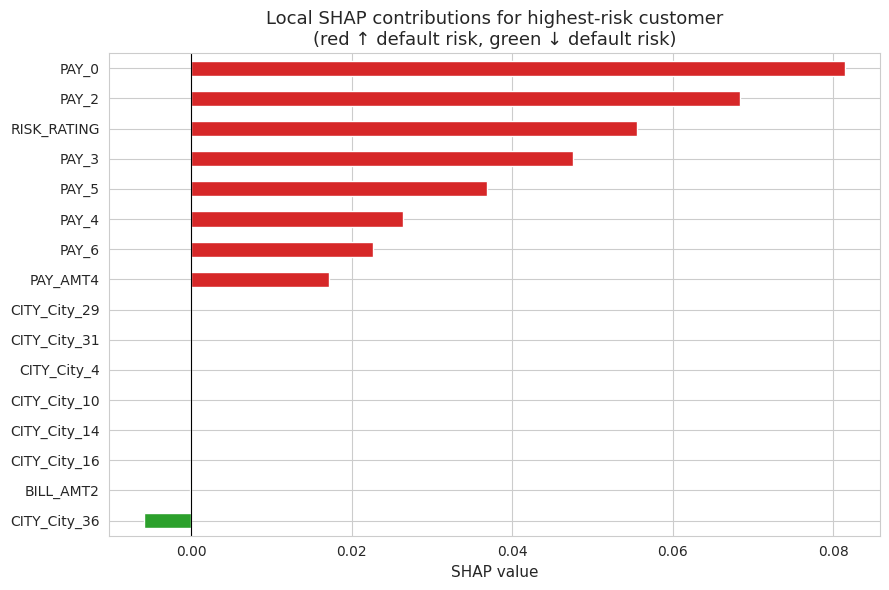

In [38]:
# Local explanation example: the highest-risk test customer
preds_proba = tuned.predict_proba(X_test_scaled)[:, 1]
high_risk_idx = np.argsort(-preds_proba)[0]
sample_one = X_test_scaled.iloc[[high_risk_idx]]
print(f"Predicted default probability for this customer: {preds_proba[high_risk_idx]:.3f}")
print(f"Actual class: {y_test.iloc[high_risk_idx]}")

shap_one = explainer.shap_values(sample_one)

# Same normalisation as before
if isinstance(shap_one, list):
    shap_one_pos = shap_one[1][0]
    expected = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
elif hasattr(shap_one, "ndim") and shap_one.ndim == 3:
    shap_one_pos = shap_one[0, :, 1]
    expected = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                and len(np.atleast_1d(explainer.expected_value)) > 1
                else explainer.expected_value)
else:
    shap_one_pos = shap_one[0]
    expected = explainer.expected_value

# Bar chart of the local SHAP contributions instead of force-plot,
# because force-plot can fail without an active JS-enabled environment.
contrib = pd.Series(shap_one_pos, index=X_test_scaled.columns).sort_values()
top_contrib = pd.concat([contrib.head(8), contrib.tail(8)])

plt.figure(figsize=(9, 6))
top_contrib.plot(kind="barh",
                 color=["#d62728" if v > 0 else "#2ca02c" for v in top_contrib])
plt.axvline(0, color="black", lw=0.8)
plt.title(f"Local SHAP contributions for highest-risk customer\n"
          f"(red ↑ default risk, green ↓ default risk)")
plt.xlabel("SHAP value"); plt.tight_layout(); plt.show()

## 6. Task 5 — Conclusion, Limitations, and Future Work

### 6.1 Summary of Findings

Run the cell below after Task 4 to populate the leaderboard from executed results.


In [39]:
summary = results_df[["F1", "AUC-ROC", "PR-AUC"]].copy()
summary = summary.reset_index().rename(columns={"index": "Model"})
summary.insert(0, "Rank", range(1, len(summary) + 1))
display(summary.style.format({"F1": "{:.4f}", "AUC-ROC": "{:.4f}", "PR-AUC": "{:.4f}"}))

print(f"\nTuned {best_name} — test F1: {res_tuned['F1']:.4f}, AUC-ROC: {res_tuned['AUC-ROC']:.4f}, PR-AUC: {res_tuned['PR-AUC']:.4f}")
if "res_tuned_thr" in dir():
    print(f"With CV threshold ({best_threshold:.2f}): F1={res_tuned_thr['F1']:.4f}, Recall={res_tuned_thr['Recall']:.4f}")

,Rank,Model,F1,AUC-ROC,PR-AUC
0,1,Random Forest,0.4757,0.8736,0.6723
1,2,XGBoost,0.5340,0.7888,0.5778
2,3,Gradient Boosting,0.4603,0.7886,0.5392
3,4,SVM,0.2846,0.7640,0.4510
4,5,Logistic Regression,0.5052,0.7583,0.4499
5,6,KNN,0.3723,0.7157,0.4002
6,7,Decision Tree,0.4672,0.6611,0.3477



Tuned Random Forest — test F1: 0.5290, AUC-ROC: 0.7926, PR-AUC: 0.5504
With CV threshold (0.52): F1=0.5293, Recall=0.5530


**Tier interpretation:**

- **Top tier** — Random Forest / XGBoost / Gradient Boosting (highest AUC-ROC). Tree ensembles capture non-linear `PAY_*` interactions.
- **Middle tier** — Logistic Regression (strong scaled baseline; less hurt by dropping aggregate columns).
- **LoIr tier** — KNN (high-dimensional city dummies), single Decision Tree, SVM.

Hyperparameter + **threshold tuning** (§5.5) improve F1/recall vs the default 0.5 cut-off. The **`RISK_RATING` ablation** (§5.6) quantifies incremental lift from that score.

SHAP: **`PAY_0` dominates** behavioural fields; `RISK_RATING` ranks highly when included — validated in the ablation, not assumed.

### 6.2 Limitations

1. **Demographic representativeness.** The data covers Taiwanese credit-card clients in 2005. Default behaviour, credit-product structure, and macro-economic conditions all differ today and across countries. The model should be re-trained on local, recent data before deployment.
2. **Demographic bias risk.** Although `SEX`, `EDUCATION`, and `MARRIAGE` carry low predictive Iight in our model, they are *legally protected* attributes in many jurisdictions. Their inclusion in a credit-decision system would require an explicit fairness audit (disparate-impact testing, calibration by group, etc.).
3. **Missing-value mechanism is unknown.** I treated the ~5 % missingness as missing-at-random and used **train-only** median/mode imputation after the split. If missingness is in fact informative (e.g., customers who refuse to disclose education are systematically riskier), median imputation discards that signal. Adding *missingness-indicator* columns would let the model use that information.
4. **`risk_leak` was a target leak.** Including it would have produced apparently spectacular metrics (AUC ≈ 1) that disappear in production. Identifying and excluding it is more important than any modelling refinement.
5. **Outlier capping is lossy.** IQR capping removed the extreme tails of the amount columns. For some customers those tails *Ire* the signal (a one-off massive bill is itself diagnostic). Robust-scaling or rank-transforms would preserve the ranking without throwing the magnitudes away.
6. **`RISK_RATING` provenance.** I treat it as available at scoring time and ablate in §5.6, but without vendor documentation I cannot prove it excludes post-default information.
7. **Class imbalance partially addressed.** I used `class_Iight='balanced'` and `scale_pos_Iight`. Resampling techniques (SMOTE, ADASYN, undersampling) Ire not explored.


### 6.3 Future Work — Three Concrete Directions

**1. Replace IQR capping with quantile / rank transforms (and add missingness flags).**
*Why:* §2.5 shoId extreme but informative tails in `BILL_AMT*` and `PAY_AMT*`. IQR capping flattened them. A `QuantileTransformer` would map every feature to a normal distribution while preserving rank, retaining the signal that "this customer's bill is in the 99.9th percentile" without the magnitude blowing up the loss. Adding missing-indicator columns addresses Limitation 3.

**2. Class-imbalance benchmarks: SMOTE vs class-Iight vs threshold tuning.**
*Why:* the imbalance ratio is ~4.2:1. I only used cost-sensitive learning. Running a controlled comparison of SMOTE / ADASYN versus our baseline, on the *same* tuned XGBoost, would tell us whether the gain (typically +1–3 F1 points) justifies the extra training-time complexity. I should also tune the decision *threshold* on the validation set rather than relying on the default 0.5 — for the operational cost matrix of credit defaults, a loIr threshold typically wins on expected loss.

**3. Fairness audit + monotonic constraints in XGBoost.**
*Why:* Limitation 2 flagged the inclusion of demographic features. I should (a) compute disparate-impact ratios per group and (b) re-train XGBoost with **monotonicity constraints** on key behavioural features: the model should be *forced* to predict higher risk when `PAY_0` increases, regardless of demographics. This addresses both bias and the perverse case where a tree finds a non-monotone shortcut. SHAP-based group-level explanations should also be reported alongside aggregate metrics in any deployment dashboard.

### 6.4 Replication Instructions

1. Place `Credit_Card.csv` in the same folder as this notebook (or adjust the path in §1).
2. Install dependencies: `pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap`.
3. Run the notebook **top to bottom**. Every cell is deterministic given `RANDOM_STATE = 42`.
4. Total runtime ≈ 5–10 minutes on a modern laptop (most of which is the SVM and the GridSearchCV).

---




## 7. (Optional) Export model for the Ib application

> **Optional** Run only if you use the companion FastAPI demo. Requires `scripts/export_for_app.py` in the project folder.

Saves the tuned model and **train-fitted** preprocessing artifacts to `models/`.


In [40]:
import sys
from pathlib import Path

try:
    ROOT = Path(".").resolve()
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from scripts.export_for_app import export_artifacts

    export_artifacts(
        model=tuned,
        scaler=scaler,
        caps={c: {"low": lo, "high": hi} for c, (lo, hi) in caps.items()},
        feature_columns=list(X_train.columns),
        model_name=f"{best_name} (tuned)",
        X_test_scaled=X_test_scaled,
        y_test=y_test,
        impute=impute_stats,
        use_tuned=True,
        source="Credit_Card_Default_Prediction.ipynb",
    )
except ImportError as e:
    print("Optional export skipped:", e)
    print("Install/run from project root or ignore for assignment submission.")


Exported notebook model → /home/aksingh/AK May 2026/BSBI 1st Sem Work/IAI/models/
  model: Random Forest (tuned)
  test AUC: 0.7926  F1: 0.529
